In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료



# 00. 데이터 가져오기

In [2]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [3]:
query = """
SELECT 
    SQLDATE,
    IsRootEvent,
    Actor1CountryCode,
    Actor2CountryCode,
    EventCode,
    EventBaseCode,
    EventRootCode,
    GoldsteinScale,
    QuadClass,
    NumMentions,
    NumArticles,
    NumSources,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat,
    ActionGeo_Long,
    ActionGeo_FullName,
    ActionGeo_CountryCode,
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE BETWEEN 20130401 AND 20261231
  AND (
    -- ✅ 핵심 수정: CountryCode 기반 필터링 (CHNGOV, CHNMIL 등 모두 포함)
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
"""

df = pandas_gbq.read_gbq(
    query,
    project_id=project_id,
    credentials=credentials,
    progress_bar_type='tqdm'   # 진행률 표시
)

print(f"총 {len(df):,}건 수집 완료")
display(df.head())

Downloading: 100%|██████████|
총 493,109건 수집 완료


,SQLDATE,IsRootEvent,Actor1CountryCode,Actor2CountryCode,EventCode,EventBaseCode,EventRootCode,GoldsteinScale,QuadClass,NumMentions,NumArticles,NumSources,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FullName,ActionGeo_CountryCode,SOURCEURL
0,20211218,0,CHN,TWN,180,180,18,-9.0,4,8,8,1,-0.871080,1,35.0000,105.0000,China,CH,https://nationalinterest.org/blog/reboot/us-sp...
1,20220918,0,CHN,TWN,045,045,04,5.0,1,1,1,1,-0.595480,2,42.1497,-74.9384,"New York, United States",US,https://www.heritage.org/defense/report/commer...
2,20220918,0,CHN,TWN,045,045,04,5.0,1,1,1,1,-0.595480,4,39.9289,116.3880,"Beijing, Beijing, China",CH,https://www.heritage.org/defense/report/commer...
3,20220918,0,TWN,CHN,045,045,04,5.0,1,4,4,1,-0.595480,4,39.9289,116.3880,"Beijing, Beijing, China",CH,https://www.heritage.org/defense/report/commer...
4,20220911,1,CHN,TWN,026,026,02,4.0,1,2,2,1,0.835073,4,24.0000,121.0000,"Republic Of China, Taiwan (general), Taiwan",TW,https://focustaiwan.tw/politics/202209180003


In [4]:
# 수집된 데이터 저장
import os
os.makedirs("data/raw", exist_ok=True)

# parquet으로 저장 (CSV보다 10배 빠른 로딩)
df.to_parquet("data/raw/gdelt_chn_twn_2013_2026.parquet", index=False)
print("저장 완료: data/raw/gdelt_chn_twn_2013_2026.parquet")

저장 완료: data/raw/gdelt_chn_twn_2013_2026.parquet


# EDA 
## Phase 1: 데이터 품질 점검
좌표 결측/ 이상값 비율 -> 이후  DBSCAN ROI 생성 가능 범위 결정

In [27]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지

In [5]:
# 1-1. 기본 현황
df.info()
df.describe()

# 1-2. 결측치 확인 (특히 GEOINT에 필수인 좌표)
df[['ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_CountryCode']].isnull().sum()

# 1-3. 좌표 유효 범위 검증 (양안 지역: 위도 18~30, 경도 118~125)
valid_geo = df[
    df['ActionGeo_Lat'].between(18, 30) & 
    df['ActionGeo_Long'].between(118, 125)
]
print(f"좌표 유효 비율: {len(valid_geo)/len(df):.1%}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493109 entries, 0 to 493108
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   SQLDATE                493109 non-null  Int64  
 1   IsRootEvent            493109 non-null  Int64  
 2   Actor1CountryCode      493109 non-null  object 
 3   Actor2CountryCode      493109 non-null  object 
 4   EventCode              493109 non-null  object 
 5   EventBaseCode          493109 non-null  object 
 6   EventRootCode          493109 non-null  object 
 7   GoldsteinScale         493107 non-null  float64
 8   QuadClass              493109 non-null  Int64  
 9   NumMentions            493109 non-null  Int64  
 10  NumArticles            493109 non-null  Int64  
 11  NumSources             493109 non-null  Int64  
 12  AvgTone                493109 non-null  float64
 13  ActionGeo_Type         493109 non-null  Int64  
 14  ActionGeo_Lat          493061 non-nu

In [6]:
# Type 분포 먼저 확인
df['ActionGeo_Type'].value_counts()

# Type 4/5 비율이 DBSCAN에 투입 가능한 데이터 규모를 결정
usable = df[df['ActionGeo_Type'].isin([4, 5])]
print(f"DBSCAN 투입 가능: {len(usable):,}건 ({len(usable)/len(df):.1%})")

DBSCAN 투입 가능: 351,411건 (71.3%)


## Phase 2: 시계열 분포 분석 (스파이크 탐지 기반)

In [7]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
df['YearMonth'] = df['SQLDATE'].dt.to_period('M')

# 월별 기사량 추이
monthly = df.groupby('YearMonth').agg(
    NumArticles=('NumArticles', 'sum'),
    AvgTone=('AvgTone', 'mean'),
    EventCount=('SQLDATE', 'count')
).reset_index()

# 시각화: 주요 긴장 사건과 대조
# 체크: 2016(트럼프 당선), 2022(펠로시 방문), 2024(대만 선거) 등 스파이크 확인

### 1. 기간 기준 비교 (7 / 14 / 30일 Rolling)
목적: 스파이크 탐지의 민감도 결정 — 짧을수록 민감, 길수록 안정적

In [8]:
df_daily = df.groupby('SQLDATE')['NumArticles'].sum().reset_index()
df_daily = df_daily.set_index('SQLDATE').asfreq('D', fill_value=0)

for window in [7, 14, 30]:
    df_daily[f'rolling_{window}'] = df_daily['NumArticles'].rolling(window).mean()
    df_daily[f'std_{window}'] = df_daily['NumArticles'].rolling(window).std()

# 시각화: 세 롤링 평균을 한 그래프에 겹쳐서 비교
# → 어떤 창이 실제 사건(펠로시 방문 등)에 가장 잘 반응하는지 육안 확인

C:\Users\user\AppData\Local\Temp\ipykernel_444992\3617664991.py:20: UserWarning: Glyph 54176 (\N{HANGUL SYLLABLE PEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_444992\3617664991.py:20: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_444992\3617664991.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_444992\3617664991.py:20: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_444992\3617664991.py:20: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_444992\3617664991.py:20: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from

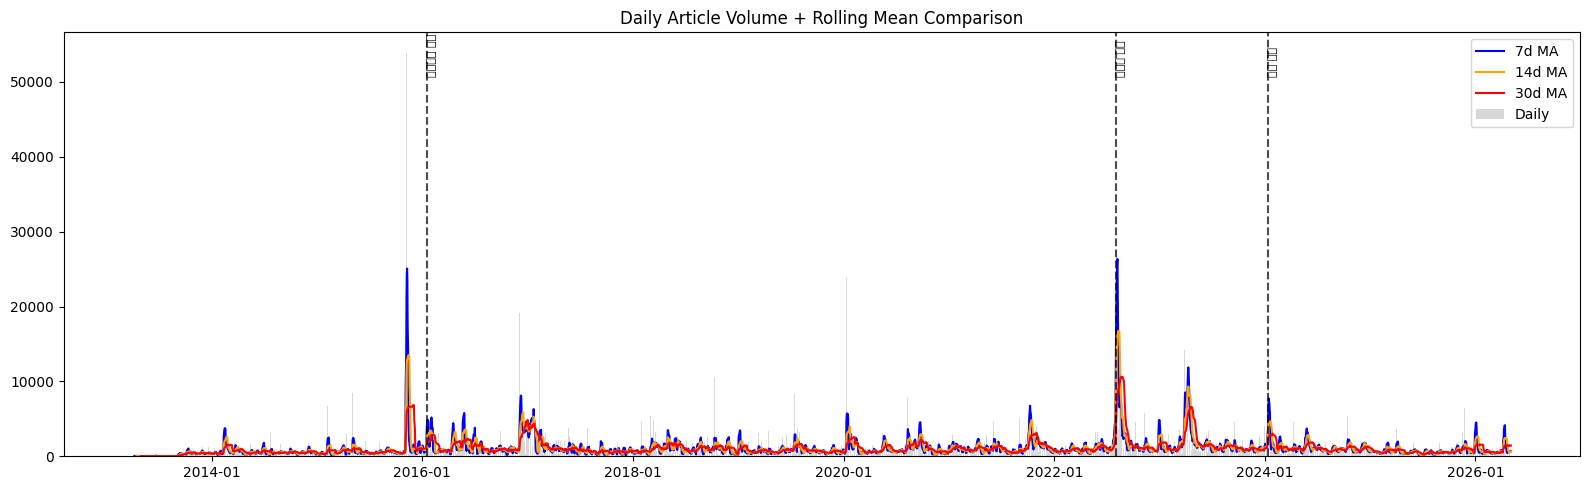

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(16, 5))

ax.bar(df_daily.index, df_daily['NumArticles'], alpha=0.3, color='gray', label='Daily')
ax.plot(df_daily.index, df_daily['rolling_7'],  color='blue',  label='7d MA')
ax.plot(df_daily.index, df_daily['rolling_14'], color='orange', label='14d MA')
ax.plot(df_daily.index, df_daily['rolling_30'], color='red',   label='30d MA')

# 알려진 사건 수직선 표시 → 어떤 window가 잘 반응하는지 육안 비교
events = {'2022-08-02': '펠로시 방문', '2024-01-13': '대만 선거', '2016-01-16': '차이잉원 당선'}
for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color='black', linestyle='--', alpha=0.7)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1]*0.9, label, rotation=90, fontsize=8)

ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.title('Daily Article Volume + Rolling Mean Comparison')
plt.tight_layout()

판단 기준: 알려진 긴장 이벤트(2022-08 펠로시, 2024-01 대만 선거) 시점에서 어떤 window가 스파이크를 가장 명확하게 잡는지 확인 → 14일이 일반적으로 균형점
보는 포인트: 수직선(실제 사건)과 rolling mean 피크가 얼마나 일치하는지

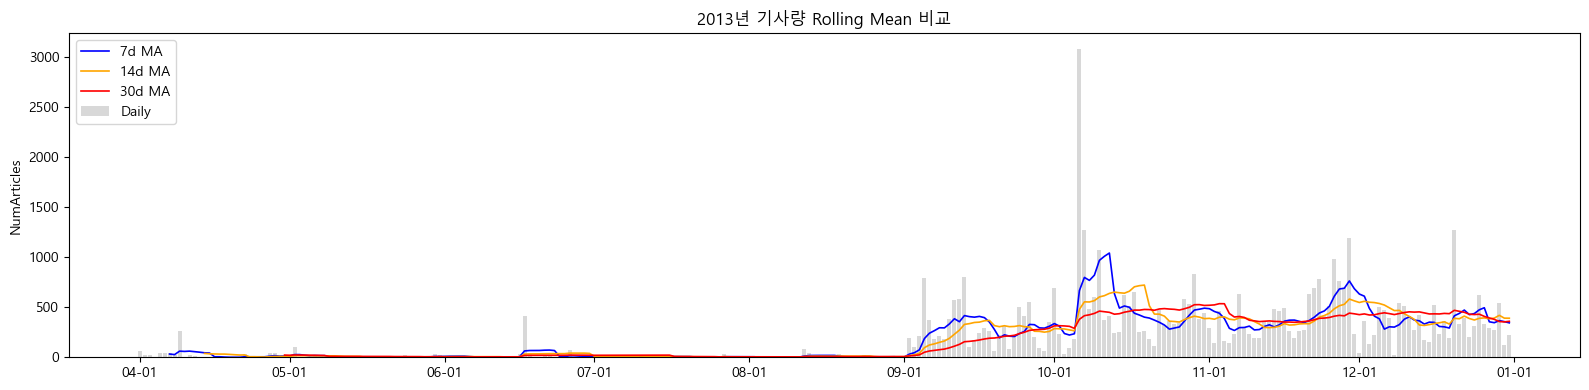

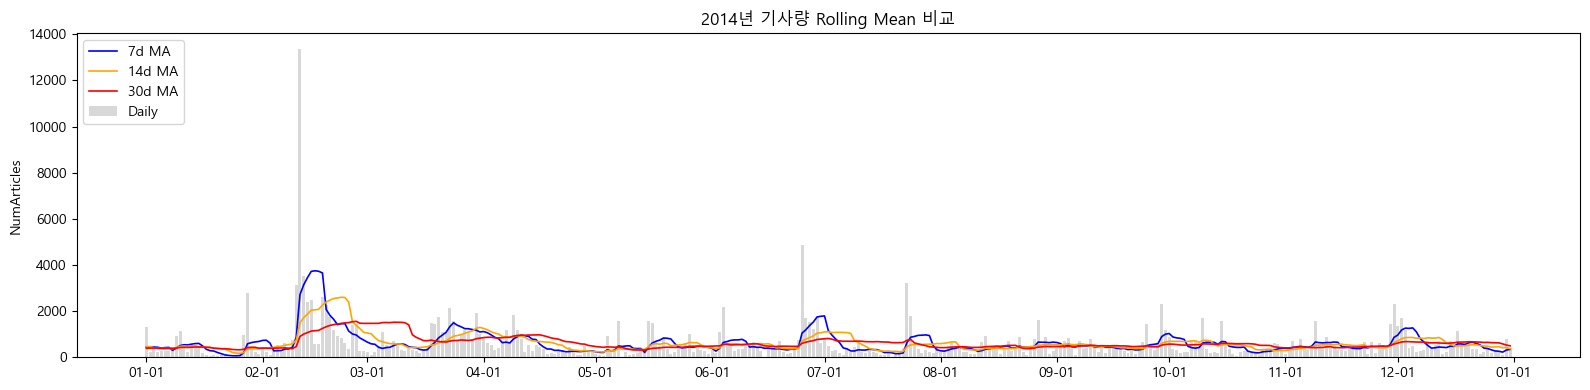

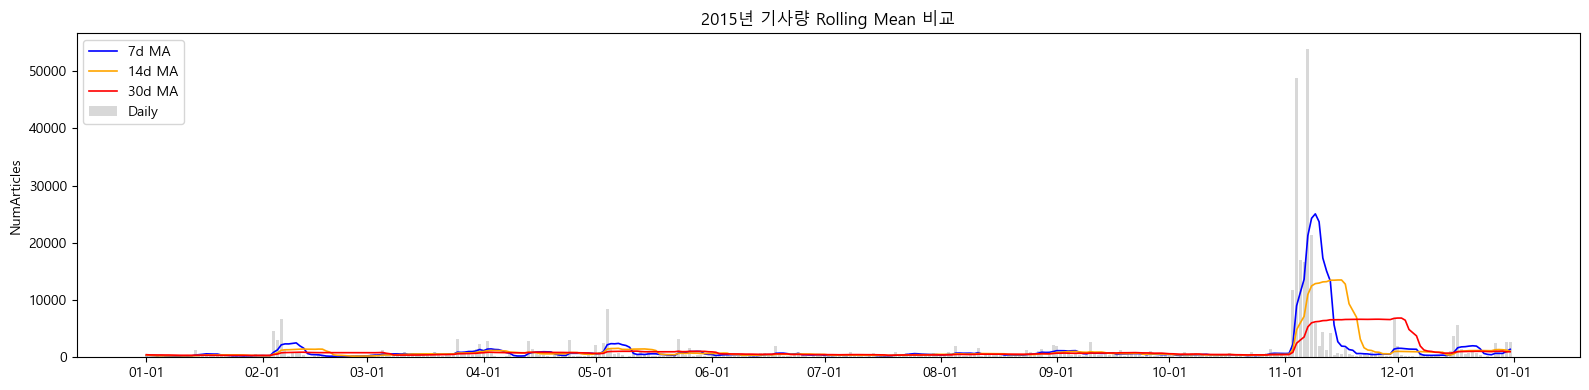

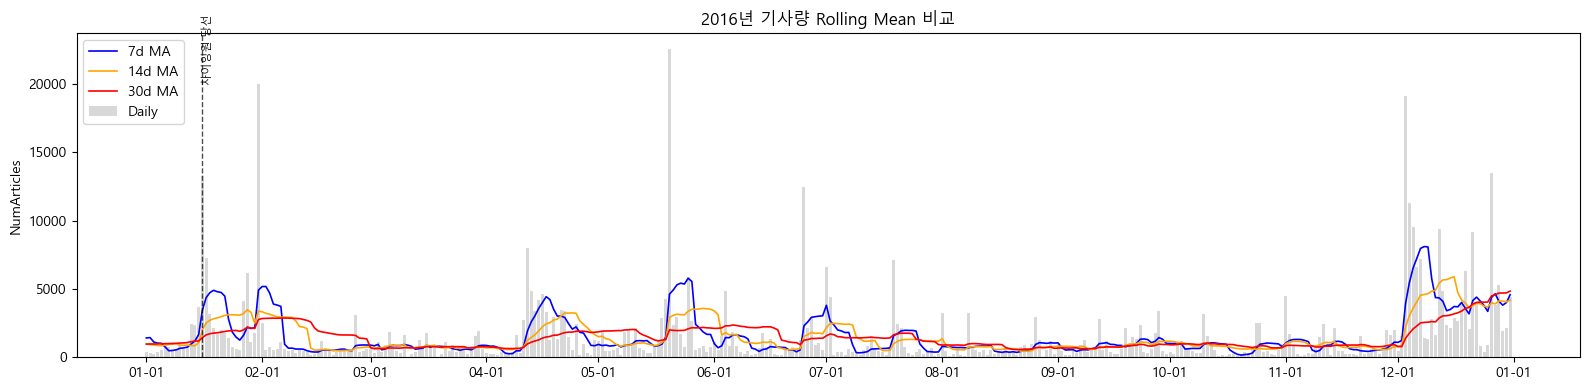

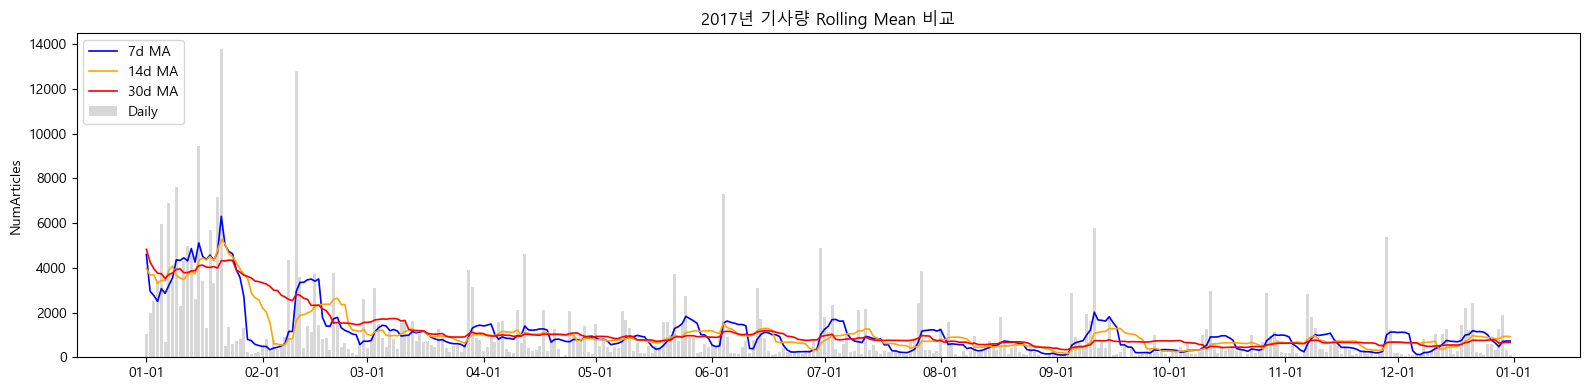

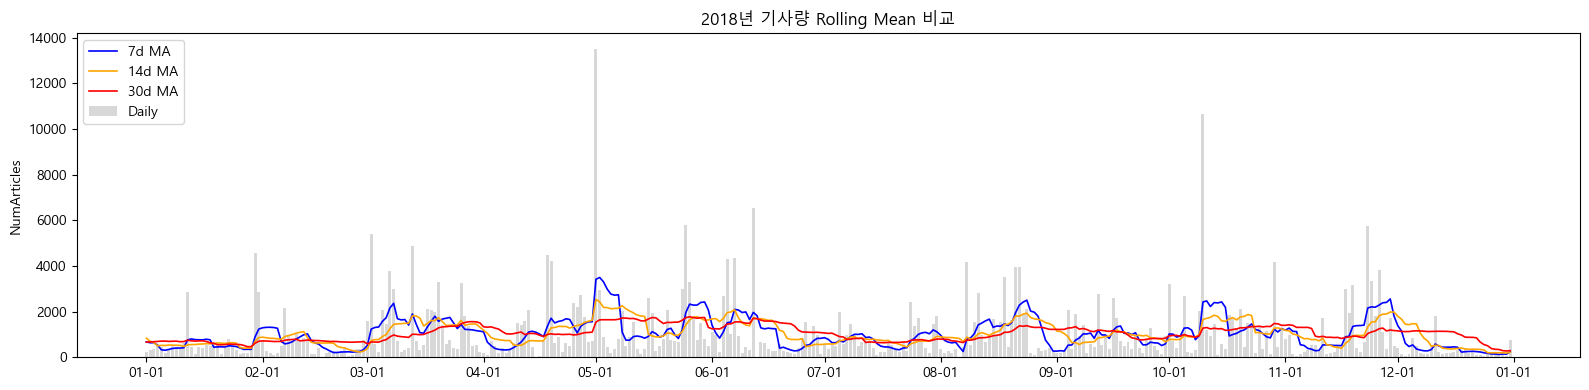

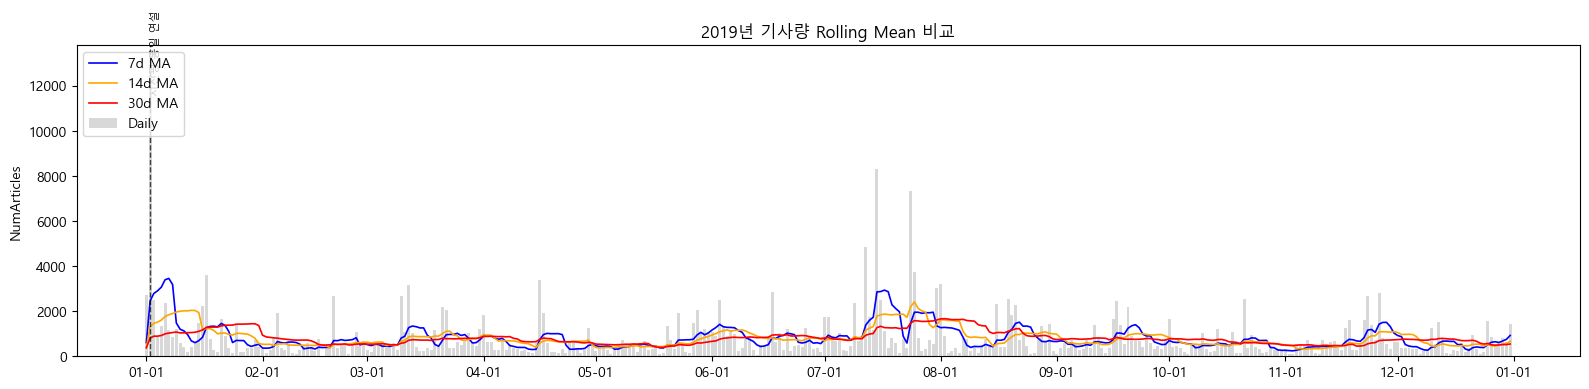

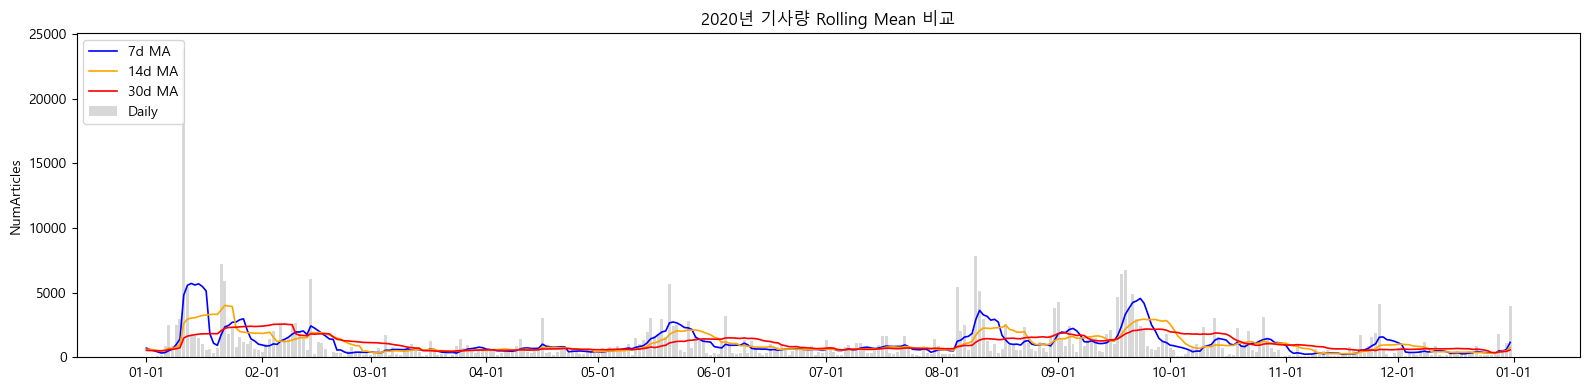

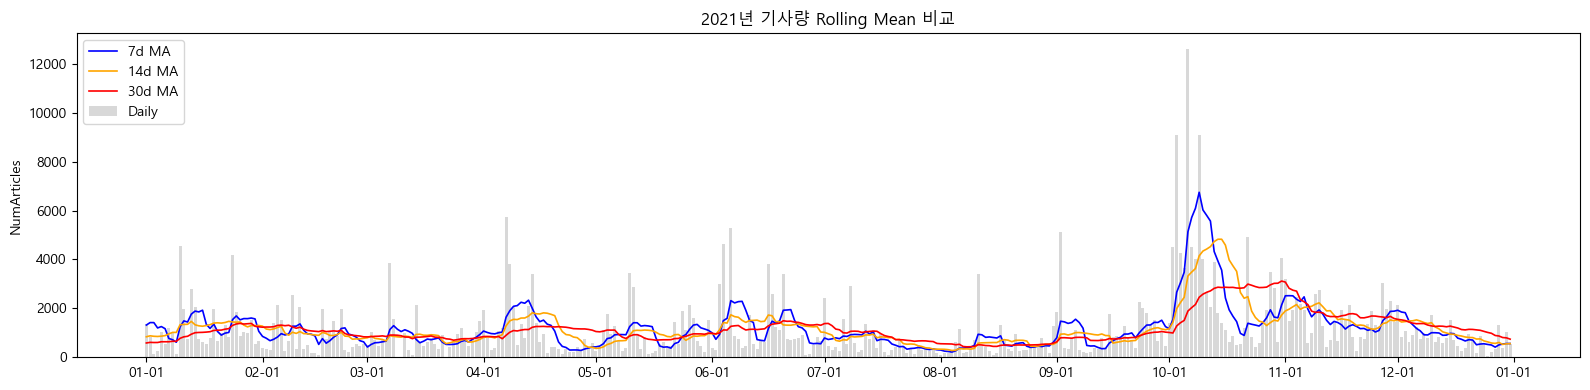

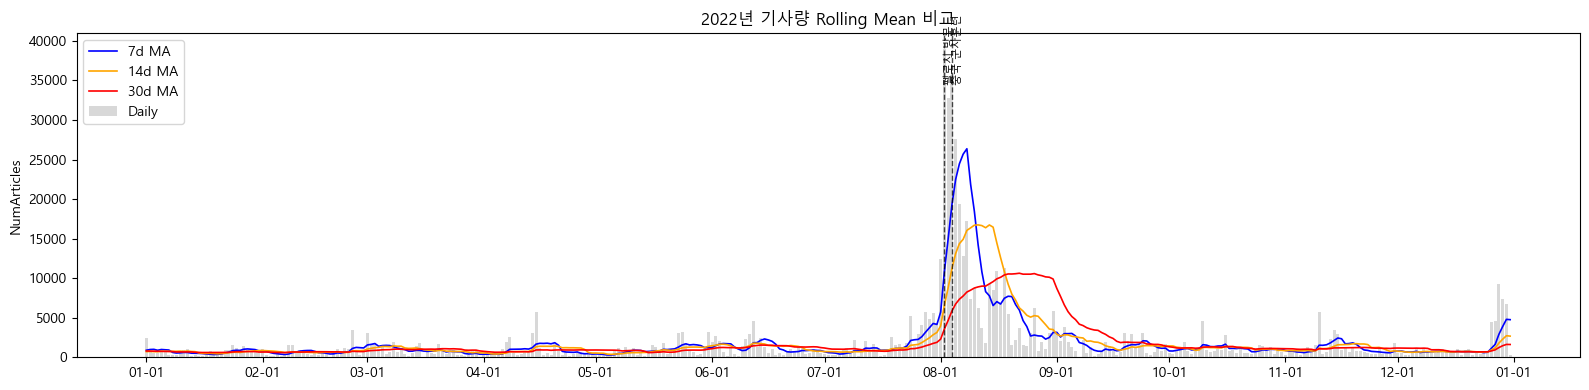

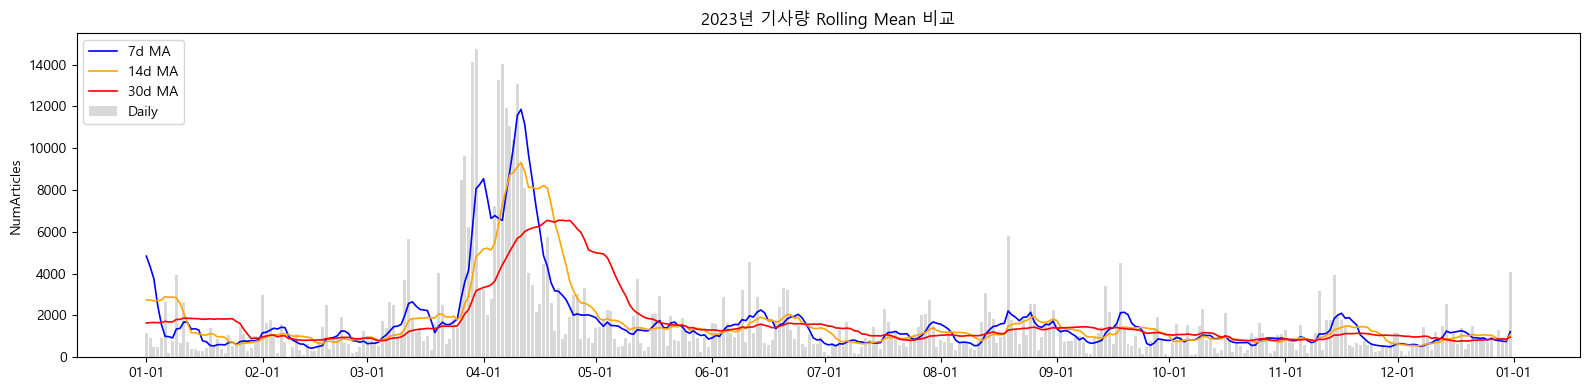

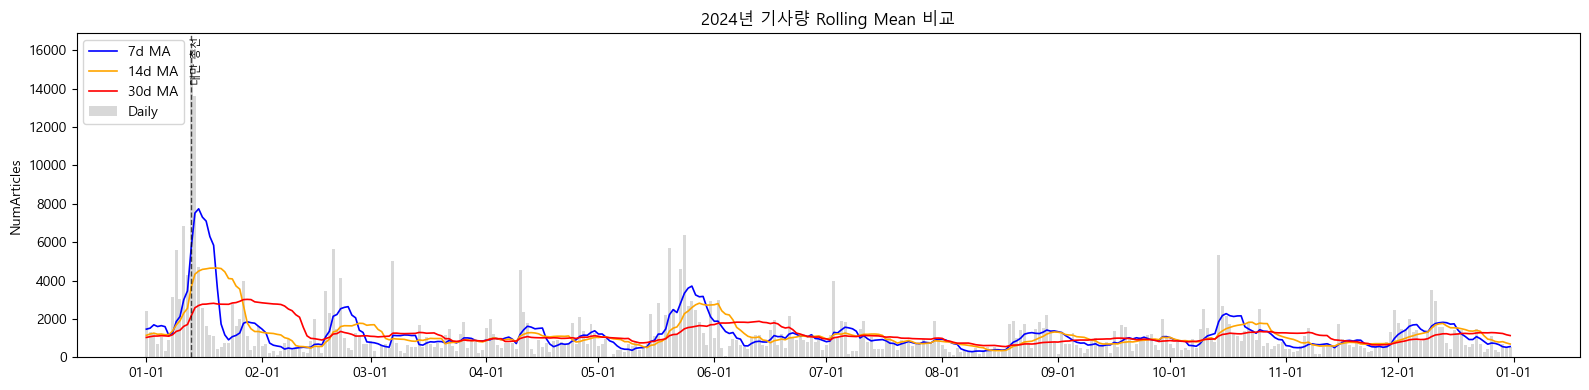

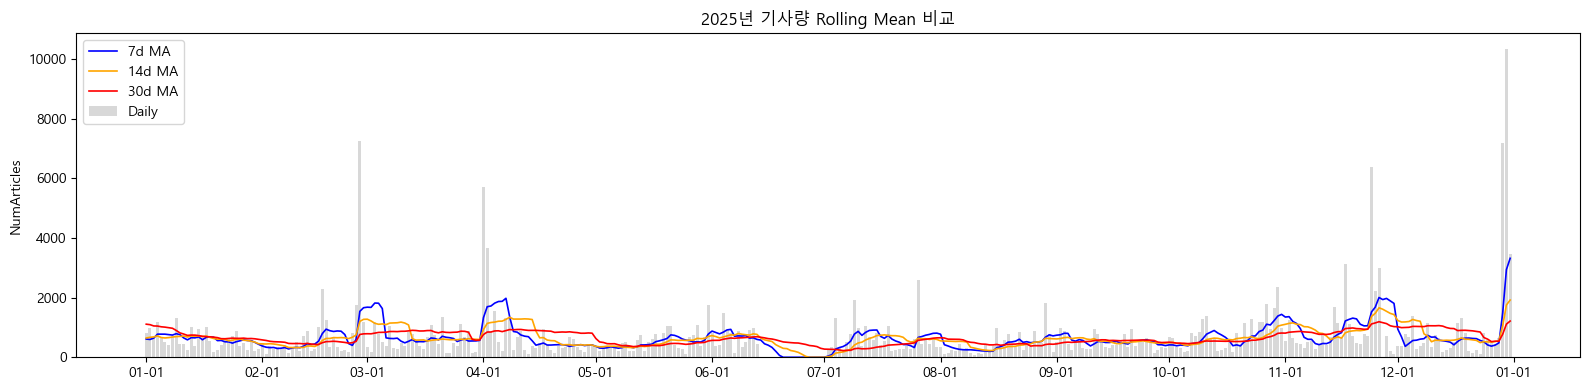

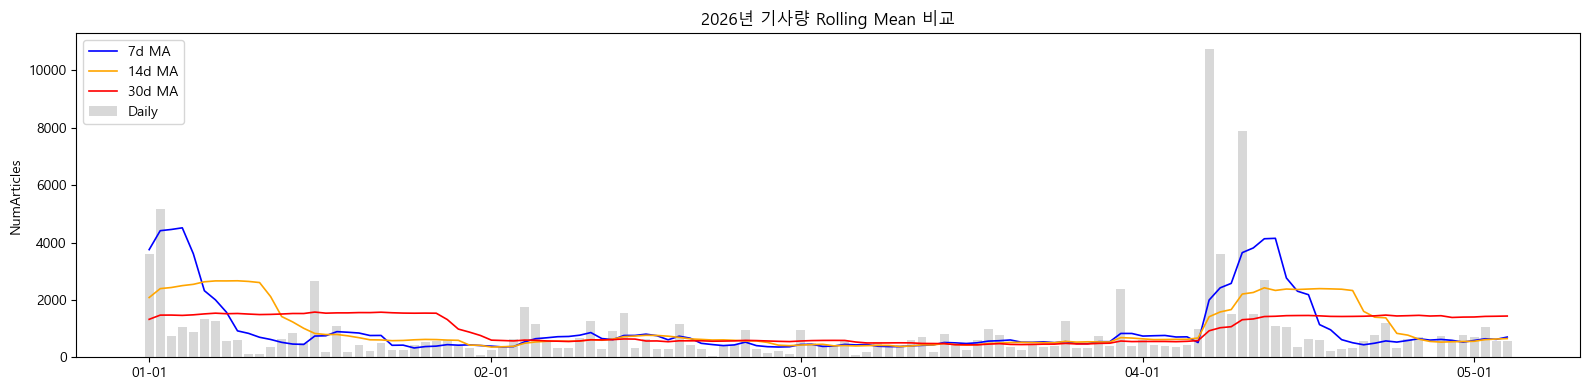

In [39]:
years = sorted(df_daily.index.year.unique())

for year in years:
    df_year = df_daily[df_daily.index.year == year]
    
    fig, ax = plt.subplots(figsize=(16, 4))
    
    ax.bar(df_year.index, df_year['NumArticles'], alpha=0.3, color='gray', label='Daily')
    ax.plot(df_year.index, df_year['rolling_7'],  color='blue',   linewidth=1.2, label='7d MA')
    ax.plot(df_year.index, df_year['rolling_14'], color='orange', linewidth=1.2, label='14d MA')
    ax.plot(df_year.index, df_year['rolling_30'], color='red',    linewidth=1.2, label='30d MA')
    
    # 해당 연도 알려진 사건 표시
    events = {
        '2016-01-16': '차이잉원 당선',
        '2019-01-02': '시진핑 통일 연설',
        '2022-08-02': '펠로시 방문',
        '2022-08-04': '중국 군사훈련',
        '2024-01-13': '대만 총선',
    }
    for date, label in events.items():
        ts = pd.Timestamp(date)
        if ts in df_year.index or (ts.year == year):
            ax.axvline(ts, color='black', linestyle='--', alpha=0.7, linewidth=1)
            ax.text(ts, ax.get_ylim()[1] * 0.85, label, rotation=90, fontsize=8)
    
    ax.set_title(f'{year}년 기사량 Rolling Mean 비교')
    ax.set_ylabel('NumArticles')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

### 2. 기사량 분포
목적: 정규분포인지 heavy-tail인지 확인 → Z-score vs IQR/Percentile 방식 선택

Skewness: 10.45
Kurtosis: 174.06


NormaltestResult(statistic=np.float64(325.5884134406266), pvalue=np.float64(1.992389918575066e-71))

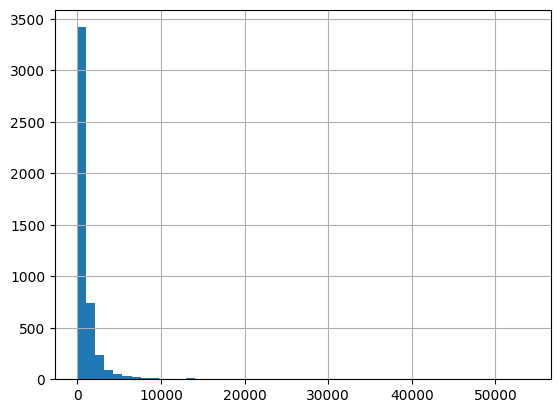

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

daily_vol = df.groupby('SQLDATE')['NumArticles'].sum()

# 분포 확인
daily_vol.hist(bins=50)
print(f"Skewness: {daily_vol.skew():.2f}")  # 2 이상이면 heavy-tail
print(f"Kurtosis: {daily_vol.kurtosis():.2f}")

# 로그 변환 후 정규성 검정
stats.normaltest(np.log1p(daily_vol))

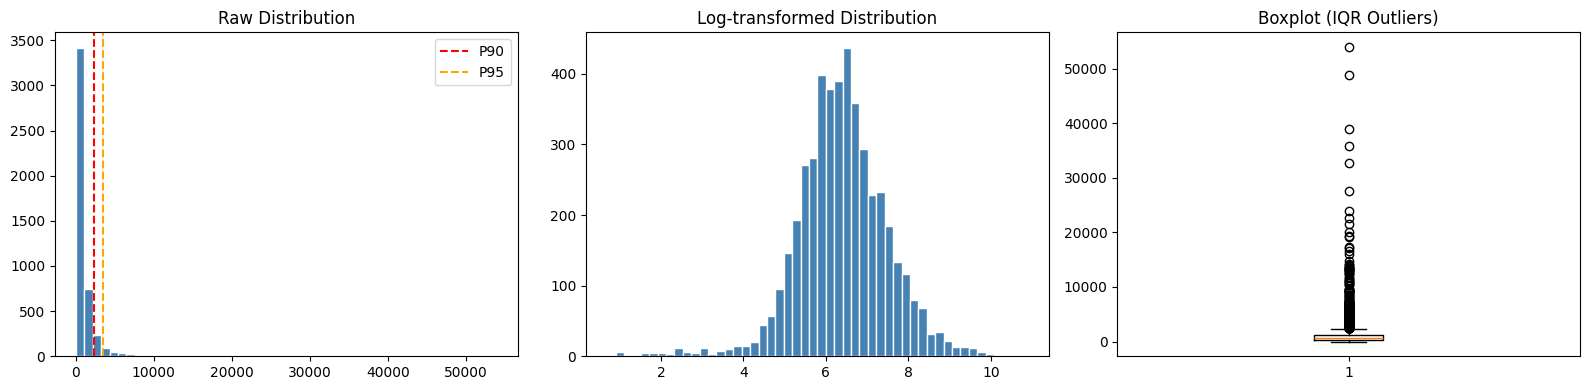

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (1) 원본 분포 — heavy-tail 확인
axes[0].hist(daily_vol, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Distribution')
axes[0].axvline(daily_vol.quantile(0.90), color='red', linestyle='--', label='P90')
axes[0].axvline(daily_vol.quantile(0.95), color='orange', linestyle='--', label='P95')
axes[0].legend()

# (2) 로그 변환 분포 — 정규성 확인
axes[1].hist(np.log1p(daily_vol), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Log-transformed Distribution')

# (3) Box plot — IQR 이상치 시각화
axes[2].boxplot(daily_vol, vert=True)
axes[2].set_title('Boxplot (IQR Outliers)')

plt.tight_layout()

### 3. 기사 증가율 (Rate of Change)
목적: 절대량이 아닌 "갑자기 늘었냐"를 포착 → 평소 기사 적은 날의 급증도 탐지

In [12]:
df_daily['pct_change_7d'] = df_daily['NumArticles'].pct_change(periods=7)
df_daily['pct_change_14d'] = df_daily['NumArticles'].pct_change(periods=14)

# 증가율 분포
df_daily['pct_change_7d'].describe(percentiles=[.75, .90, .95, .99])

# 후보 임계값 시각화
threshold_candidates = [1.0, 1.5, 2.0]  # +100%, +150%, +200%
for t in threshold_candidates:
    spikes = df_daily[df_daily['pct_change_7d'] > t]
    print(f"임계값 {t*100:.0f}%: {len(spikes)}건 스파이크")

임계값 100%: 1255건 스파이크
임계값 150%: 994건 스파이크
임계값 200%: 803건 스파이크


In [ ]:
# 예: 기사량 상위 10% AND 전주 대비 50% 이상 증가
# spike_candidates = df_daily[
#     (df_daily['NumArticles'] > df_daily['NumArticles'].quantile(0.90)) &
#     (df_daily['pct_change_7d'] > 0.5)
# ]

핵심: 증가율과 절대량을 AND 조건으로 결합해야 노이즈 줄어듦
보는 포인트: 상/하단 패널이 동기화 — 빨간 막대(스파이크)와 증가율 피크가 같은 시점인지 확인

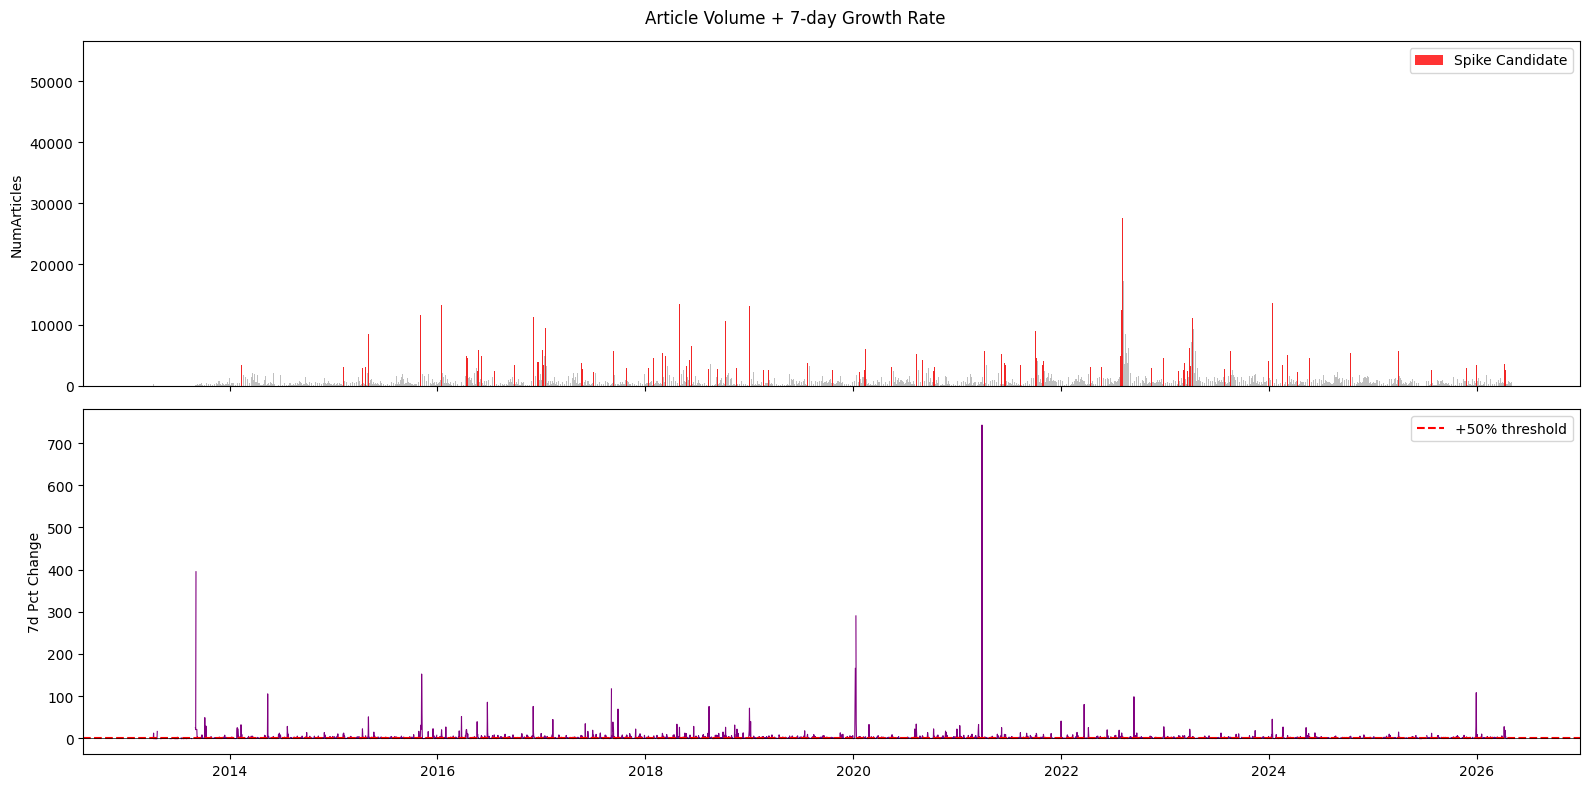

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# (1) 상단: 기사량 + 스파이크 후보 하이라이트
axes[0].bar(df_daily.index, df_daily['NumArticles'], color='gray', alpha=0.5)
spike_mask = (
    (df_daily['NumArticles'] > df_daily['NumArticles'].quantile(0.90)) &
    (df_daily['pct_change_7d'] > 0.5)
)
axes[0].bar(df_daily.index[spike_mask], df_daily['NumArticles'][spike_mask], color='red', alpha=0.8, label='Spike Candidate')
axes[0].set_ylabel('NumArticles')
axes[0].legend()

# (2) 하단: 7일 증가율
axes[1].plot(df_daily.index, df_daily['pct_change_7d'], color='purple', linewidth=0.8)
axes[1].axhline(0.5, color='red', linestyle='--', label='+50% threshold')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('7d Pct Change')
axes[1].legend()

plt.suptitle('Article Volume + 7-day Growth Rate')
plt.tight_layout()

### 4. AvgTone + GoldsteinScale 결합
목적: 기사량 급증이 실제 군사적 긴장인지, 단순 외교 이벤트인지 구분

In [29]:
daily_tone = df.groupby('SQLDATE').agg(
    NumArticles=('NumArticles', 'sum'),
    AvgTone=('AvgTone', 'mean'),
    GoldsteinScale=('GoldsteinScale', 'mean'),
    NegativeEventRatio=('GoldsteinScale', lambda x: (x < -5).mean())
).reset_index()

# Tone과 Volume의 상관관계
daily_tone[['NumArticles', 'AvgTone', 'GoldsteinScale']].corr()

# 복합 스파이크 정의 후보
# 기사 급증(volume spike) + 부정 톤(AvgTone < -3) + 위협적 이벤트(Goldstein < -5)

,NumArticles,AvgTone,GoldsteinScale
NumArticles,1.000000,-0.121019,-0.035255
AvgTone,-0.121019,1.000000,0.414608
GoldsteinScale,-0.035255,0.414608,1.000000


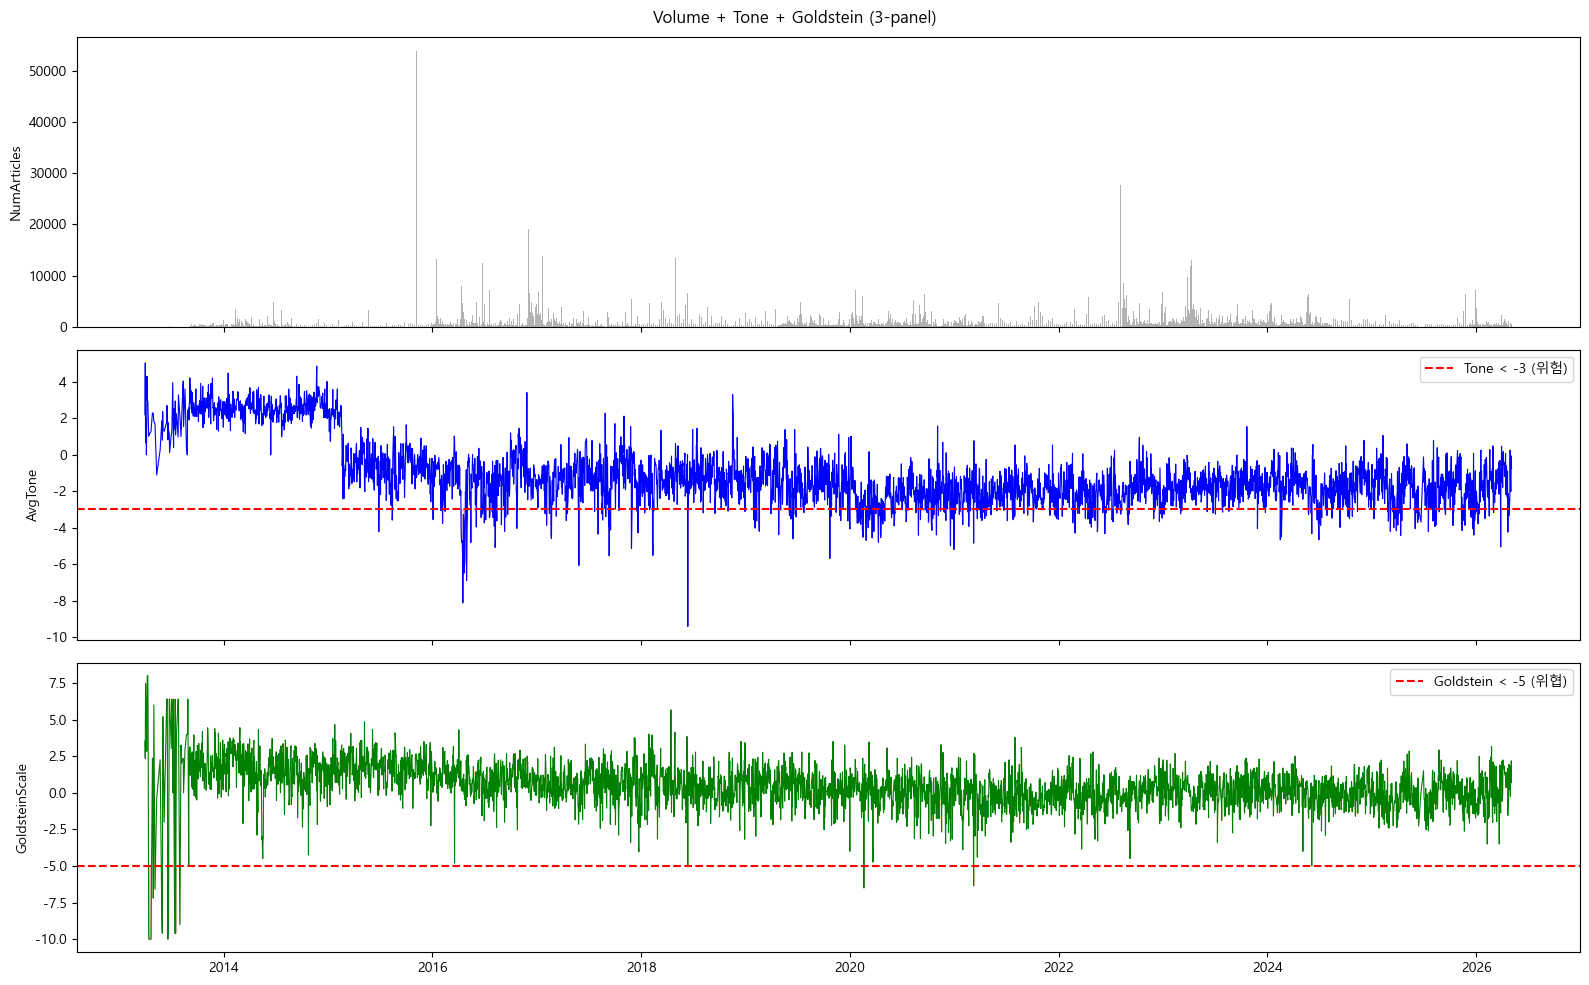

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# (1) 기사량
axes[0].bar(daily_tone['SQLDATE'], daily_tone['NumArticles'], color='gray', alpha=0.6)
axes[0].set_ylabel('NumArticles')

# (2) AvgTone (부정일수록 위험)
axes[1].plot(daily_tone['SQLDATE'], daily_tone['AvgTone'], color='blue', linewidth=0.8)
axes[1].axhline(-3, color='red', linestyle='--', label='Tone < -3 (위험)')
axes[1].fill_between(daily_tone['SQLDATE'], daily_tone['AvgTone'], -3,
                     where=daily_tone['AvgTone'] < -3, color='red', alpha=0.2)
axes[1].set_ylabel('AvgTone')
axes[1].legend()

# (3) GoldsteinScale (부정일수록 군사적 위협)
axes[2].plot(daily_tone['SQLDATE'], daily_tone['GoldsteinScale'], color='green', linewidth=0.8)
axes[2].axhline(-5, color='red', linestyle='--', label='Goldstein < -5 (위협)')
axes[2].fill_between(daily_tone['SQLDATE'], daily_tone['GoldsteinScale'], -5,
                     where=daily_tone['GoldsteinScale'] < -5, color='red', alpha=0.2)
axes[2].set_ylabel('GoldsteinScale')
axes[2].legend()

plt.suptitle('Volume + Tone + Goldstein (3-panel)')
plt.tight_layout()

Text(0.5, 1.0, 'Tone vs Goldstein (색: 기사량)')

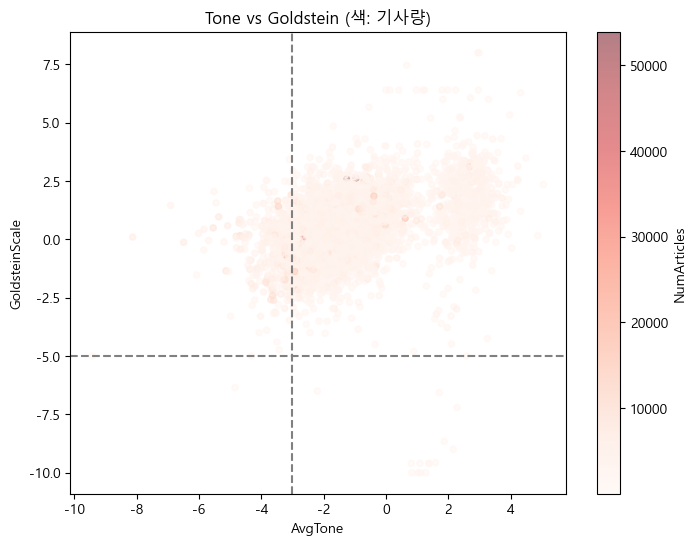

In [31]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(daily_tone['AvgTone'], daily_tone['GoldsteinScale'],
                 c=daily_tone['NumArticles'], cmap='Reds', alpha=0.5, s=20)
plt.colorbar(sc, label='NumArticles')
plt.axvline(-3, color='gray', linestyle='--')
plt.axhline(-5, color='gray', linestyle='--')
plt.xlabel('AvgTone')
plt.ylabel('GoldsteinScale')
plt.title('Tone vs Goldstein (색: 기사량)')
# 좌하단 사분면 = 부정 톤 + 위협적 이벤트 → 핵심 감시 구역

판단: 세 지표가 동시에 임계값을 넘는 날 → 고신뢰 스파이크로 분류
보는 포인트: 세 패널이 동시에 빨간 영역에 들어오는 날 → 고신뢰 스파이크

추가로 Tone-Goldstein 산점도도 유용합니다:

### 5. 중복 기사 탐지 (같은 사건 판별)
목적: 동일 사건의 중복 보도를 제거해야 실제 이벤트 수 계산 가능

In [ ]:
# 1단계: 날짜 + CAMEO 코드 기준 단순 중복 확인
dup_check = df.groupby(['SQLDATE', 'EventCode', 'ActionGeo_FullName']).size()
print(f"같은 날/코드/지역 중복: {(dup_check > 1).sum()}건")

# 2단계: IsRootEvent 필터 (GDELT 공식 중복 제거 플래그)
df_root = df[df['IsRootEvent'] == 1]
print(f"IsRootEvent 필터 후: {len(df_root):,}건 ({len(df_root)/len(df):.1%})")

# 3단계: 임베딩 전 사전 필터 — 같은 날 + 같은 EventCode면 동일 사건 가능성 높음
df['event_key'] = df['SQLDATE'].astype(str) + '_' + df['EventCode'] + '_' + df['ActionGeo_CountryCode'].fillna('')
print(f"고유 이벤트 키: {df['event_key'].nunique():,}건")

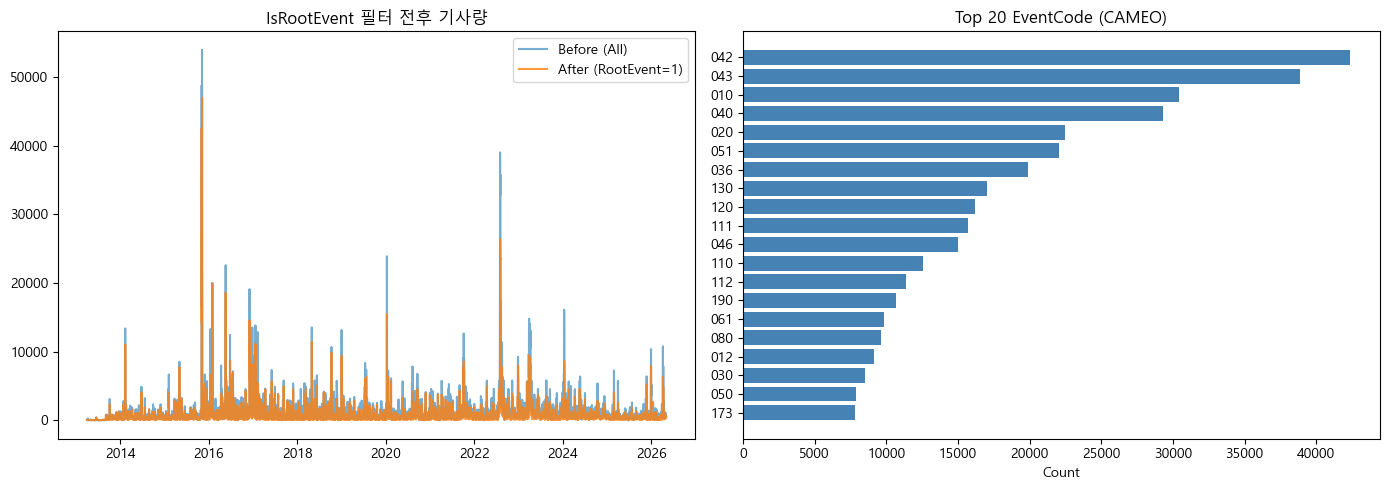

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) IsRootEvent 필터 전후 기사량 비교
before = df.groupby('SQLDATE')['NumArticles'].sum()
after  = df[df['IsRootEvent'] == 1].groupby('SQLDATE')['NumArticles'].sum()

axes[0].plot(before.index, before.values, label='Before (All)', alpha=0.6)
axes[0].plot(after.index,  after.values,  label='After (RootEvent=1)', alpha=0.8)
axes[0].set_title('IsRootEvent 필터 전후 기사량')
axes[0].legend()

# (2) EventCode별 기사 건수 Top 20 막대그래프
top_codes = df['EventCode'].value_counts().head(20)
axes[1].barh(top_codes.index.astype(str), top_codes.values, color='steelblue')
axes[1].set_title('Top 20 EventCode (CAMEO)')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()

IsRootEvent = 1이 가장 빠른 중복 제거 수단 — 임베딩 클러스터링 전에 먼저 적용하면 OpenAI API 비용도 절감됨
보는 포인트:

좌: 필터 후 노이즈가 얼마나 줄었는지 (비율 확인)
우: 군사 관련 코드(19x, 18x)가 상위에 있는지, 외교 코드(03x, 04x)가 대부분인지

## 임계값 설정 EDA
기간 + 증가율 + 최소 기사량 — 한번에 비교

In [19]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')
daily = df.groupby('SQLDATE')['NumArticles'].sum().asfreq('D', fill_value=0)

# 후보 파라미터 격자
windows     = [7, 14, 30]
rate_thres  = [0.5, 1.0, 1.5]   # 증가율
vol_thres   = [0.80, 0.85, 0.90] # 최소 기사량 Percentile

results = []
for w in windows:
    rolling_mean = daily.rolling(w).mean()
    rolling_std  = daily.rolling(w).std()
    pct_change   = daily.pct_change(periods=w)

    for rt in rate_thres:
        for vp in vol_thres:
            vol_min = daily.quantile(vp)
            mask = (pct_change > rt) & (daily > vol_min)
            results.append({
                'window': w, 'rate_threshold': rt, 'vol_percentile': vp,
                'spike_count': mask.sum(),
                'spike_dates': daily[mask].index.tolist()
            })

result_df = pd.DataFrame(results)
print(result_df.to_string())

    window  rate_threshold  vol_percentile  spike_count                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

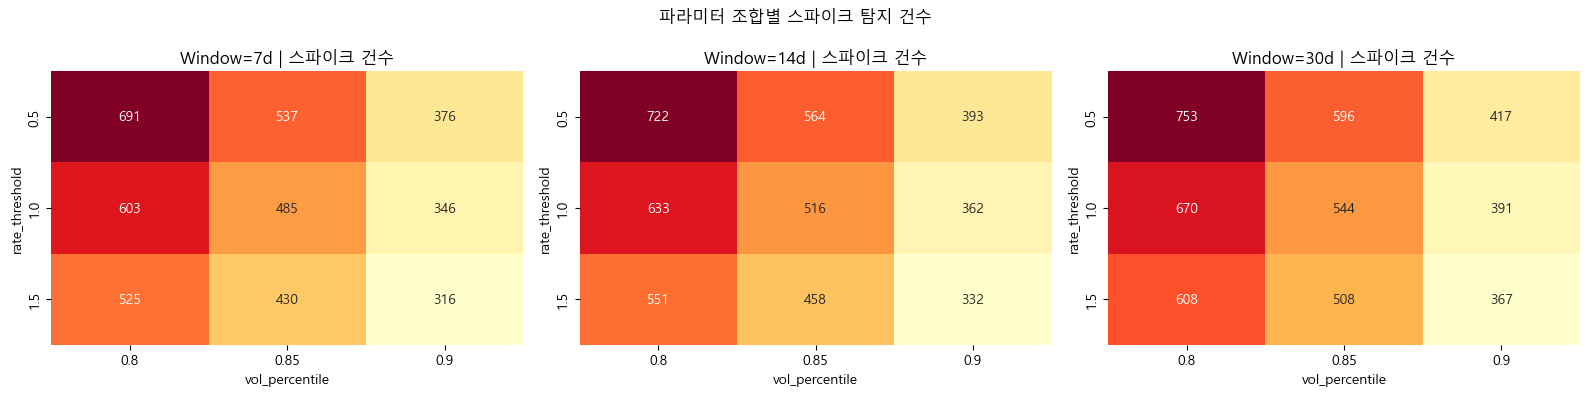

In [33]:
# 조합별 스파이크 수 히트맵 (window별로 분리)
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, w in enumerate(windows):
    pivot = result_df[result_df['window'] == w].pivot(
        index='rate_threshold', columns='vol_percentile', values='spike_count'
    )
    sns.heatmap(pivot, annot=True, fmt='d', ax=axes[i],
                cmap='YlOrRd', cbar=False)
    axes[i].set_title(f'Window={w}d | 스파이크 건수')

plt.suptitle('파라미터 조합별 스파이크 탐지 건수')
plt.tight_layout()

판단 기준: 스파이크가 너무 많으면(>30건) 과탐, 너무 적으면(<5건) 미탐 → 10~20건 구간의 조합 후보로 선정

### 알려진 사건과 대조 검증

In [21]:
# 실제 긴장 고조 사건 레퍼런스
ground_truth = pd.to_datetime([
    '2016-01-16',  # 차이잉원 당선
    '2019-01-02',  # 시진핑 통일 연설
    '2022-08-02',  # 펠로시 방문
    '2022-08-04',  # 중국 군사훈련
    '2024-01-13',  # 대만 총선
])

# 선택한 조합의 스파이크 날짜와 ±7일 이내 매칭 여부
def evaluate_combo(spike_dates, ground_truth, tolerance_days=7):
    hit, miss = 0, 0
    for gt in ground_truth:
        matched = any(abs((pd.Timestamp(sd) - gt).days) <= tolerance_days 
                      for sd in spike_dates)
        if matched: hit += 1
        else: miss += 1
    return {'hit': hit, 'miss': miss, 'recall': hit / len(ground_truth)}

for _, row in result_df.iterrows():
    score = evaluate_combo(row['spike_dates'], ground_truth)
    result_df.loc[_, ['hit', 'miss', 'recall']] = score['hit'], score['miss'], score['recall']

# recall 높고 spike_count 적은 조합이 최적
result_df.sort_values(['recall', 'spike_count'], ascending=[False, True]).head(10)

,window,rate_threshold,vol_percentile,spike_count,spike_dates,hit,miss,recall
8,7,1.5,0.90,316,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
17,14,1.5,0.90,332,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
5,7,1.0,0.90,346,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
14,14,1.0,0.90,362,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
26,30,1.5,0.90,367,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
2,7,0.5,0.90,376,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
23,30,1.0,0.90,391,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
11,14,0.5,0.90,393,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
20,30,0.5,0.90,417,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0
7,7,1.5,0.85,430,"[2013-10-06 00:00:00, 2014-01-28 00:00:00, 201...",5.0,0.0,1.0


## 이벤트 중요도  — AvgTone + GoldsteinScale 활용
두 지표의 특성 차이 먼저 파악

| 지표	| 범위	| 의미	| 한계| 
| -----| -----| -----| ----| 
| AvgTone| 	-100 ~ +100	| 기사의 감정적 분위기	| 주관적, 미디어 편향 영향| 
| GoldsteinScale| 	-10 ~ +10	| 이벤트 행동의 객관적 위협도| 	코드 기반, 문맥 무시| 

→ 둘을 결합하면 상호 보완

In [36]:
daily_tone = df.groupby('SQLDATE').agg(
    NumArticles   = ('NumArticles', 'sum'),
    AvgTone       = ('AvgTone', 'mean'),
    GoldsteinMean = ('GoldsteinScale', 'mean'),
    GoldsteinNeg  = ('GoldsteinScale', lambda x: (x < -5).mean()),  # 위협 이벤트 비율
).reset_index()

### 정규화 후 중요도 점수 계산

In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# AvgTone은 낮을수록 위험 → 부호 반전
daily_tone['tone_score']      = scaler.fit_transform(-daily_tone[['AvgTone']])
daily_tone['goldstein_score'] = scaler.fit_transform(-daily_tone[['GoldsteinMean']])
daily_tone['neg_ratio_score'] = scaler.fit_transform(daily_tone[['GoldsteinNeg']])

# 가중치는 추후 실험으로 결정 — 지금은 균등 적용
w_tone, w_gold, w_neg = 0.33, 0.33, 0.34

daily_tone['importance_score'] = (
    w_tone * daily_tone['tone_score'] +
    w_gold * daily_tone['goldstein_score'] +
    w_neg  * daily_tone['neg_ratio_score']
)

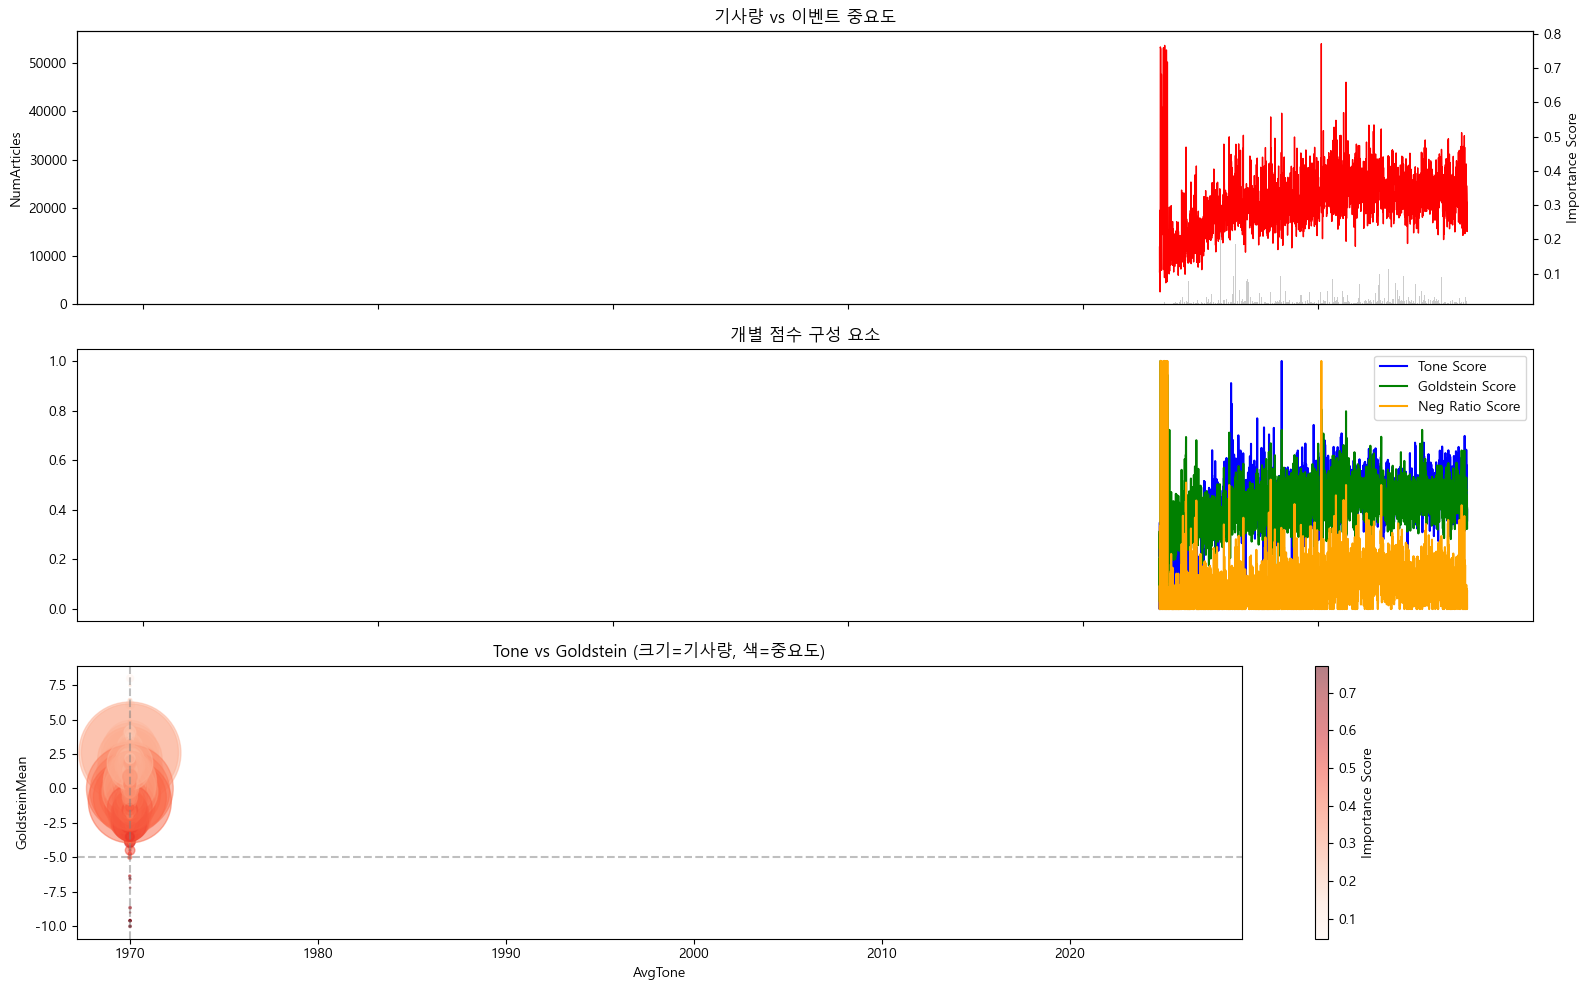

In [38]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# (1) 기사량 + importance_score 오버레이
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.bar(daily_tone['SQLDATE'], daily_tone['NumArticles'], color='gray', alpha=0.4, label='NumArticles')
ax2.plot(daily_tone['SQLDATE'], daily_tone['importance_score'], color='red', linewidth=1, label='Importance Score')
ax1.set_ylabel('NumArticles')
ax2.set_ylabel('Importance Score')
axes[0].set_title('기사량 vs 이벤트 중요도')

# (2) Tone / Goldstein 개별 추이
axes[1].plot(daily_tone['SQLDATE'], daily_tone['tone_score'],      label='Tone Score',      color='blue')
axes[1].plot(daily_tone['SQLDATE'], daily_tone['goldstein_score'], label='Goldstein Score', color='green')
axes[1].plot(daily_tone['SQLDATE'], daily_tone['neg_ratio_score'], label='Neg Ratio Score', color='orange')
axes[1].legend()
axes[1].set_title('개별 점수 구성 요소')

# (3) Tone vs Goldstein 산점도 (기사량 크기)
sc = axes[2].scatter(daily_tone['AvgTone'], daily_tone['GoldsteinMean'],
                     c=daily_tone['importance_score'], cmap='Reds',
                     s=daily_tone['NumArticles']/10, alpha=0.5)
plt.colorbar(sc, ax=axes[2], label='Importance Score')
axes[2].axvline(-3, color='gray', linestyle='--', alpha=0.5)
axes[2].axhline(-5, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('AvgTone')
axes[2].set_ylabel('GoldsteinMean')
axes[2].set_title('Tone vs Goldstein (크기=기사량, 색=중요도)')

plt.tight_layout()

### 최종 스파이크 후보 통합


In [26]:
from sklearn.preprocessing import MinMaxScaler

daily_final = daily_tone.set_index('SQLDATE').copy()

daily_final['vol_score'] = MinMaxScaler().fit_transform(daily_final[['NumArticles']])

daily_final['spike_score'] = (
    0.5 * daily_final['vol_score'] +
    0.5 * daily_final['importance_score']
)

threshold = daily_final['spike_score'].quantile(0.90)
spikes = daily_final[daily_final['spike_score'] > threshold]
print(f"최종 스파이크 후보: {len(spikes)}건")
spikes.sort_values('spike_score', ascending=False).head(20)

최종 스파이크 후보: 466건


,NumArticles,AvgTone,GoldsteinMean,GoldsteinNeg,tone_score,goldstein_score,neg_ratio_score,importance_score,vol_score,spike_score
SQLDATE,,,,,,,,,,
2015-11-07,53928,-1.259306,2.575332,0.027830,0.436080,0.301370,0.027830,0.252821,1.000000,0.626411
2015-11-04,48767,-0.967028,2.620088,0.027078,0.415876,0.298884,0.027078,0.245077,0.904297,0.574687
2022-08-02,39003,-2.674536,0.006466,0.126120,0.533911,0.444085,0.126120,0.365620,0.723237,0.544428
2022-08-04,35733,-2.857378,-0.937767,0.205529,0.546550,0.496543,0.205529,0.414101,0.662599,0.538350
2022-08-03,32741,-2.516693,-0.206971,0.151206,0.523000,0.455943,0.151206,0.374461,0.607117,0.490789
2022-08-05,27606,-3.219548,-0.658589,0.193158,0.571586,0.481033,0.193158,0.413038,0.511896,0.462467
2020-02-19,10,-2.199224,-6.500000,1.000000,0.501054,0.805556,1.000000,0.771181,0.000167,0.385674
2022-08-06,19325,-3.257250,-0.482562,0.193357,0.574192,0.471253,0.193357,0.410738,0.358336,0.384537
2013-06-20,4,0.828157,-10.000000,1.000000,0.291780,1.000000,1.000000,0.766287,0.000056,0.383172
